In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

In [32]:
import pandas as pd

file_path = "C:\\Users\\DELL\\Downloads\\pl-tables-1993-2024.csv"
data = pd.read_csv(file_path)   # yaha ab data naam use karo

print(data.head())


   season_end_year            team  position  played  won  drawn  lost  gf  \
0             1993  Manchester Utd         1      42   24     12     6  67   
1             1993     Aston Villa         2      42   21     11    10  57   
2             1993    Norwich City         3      42   21      9    12  61   
3             1993       Blackburn         4      42   20     11    11  68   
4             1993             QPR         5      42   17     12    13  63   

   ga  gd  points                                 notes  
0  31  36      84  → Champions League via league finish  
1  40  17      74          → UEFA Cup via league finish  
2  65  -4      72        → UEFA Cup via league finish 1  
3  46  22      71                                   NaN  
4  55   8      63                                   NaN  


In [37]:
# 2. Basic Info
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

Shape of dataset: (646, 12)

Data types:
 season_end_year     int64
team               object
position            int64
played              int64
won                 int64
drawn               int64
lost                int64
gf                  int64
ga                  int64
gd                  int64
points              int64
notes              object
dtype: object

First 5 rows:
    season_end_year            team  position  played  won  drawn  lost  gf  \
0             1993  Manchester Utd         1      42   24     12     6  67   
1             1993     Aston Villa         2      42   21     11    10  57   
2             1993    Norwich City         3      42   21      9    12  61   
3             1993       Blackburn         4      42   20     11    11  68   
4             1993             QPR         5      42   17     12    13  63   

   ga  gd  points                                 notes  
0  31  36      84  → Champions League via league finish  
1  40  17      74          → UE

In [9]:
# 3. Missing values
print("\nMissing Values:\n", df.isnull().sum())



Missing Values:
 season_end_year      0
team                 0
position             0
played               0
won                  0
drawn                0
lost                 0
gf                   0
ga                   0
gd                   0
points               0
notes              320
dtype: int64


In [11]:
# 4. Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [13]:
# 5. Summary statistics
print("\nNumeric Summary:\n", df.describe())
print("\nCategorical Summary:\n", df.describe(include=['object']))


Numeric Summary:
        season_end_year    position      played         won       drawn  \
count       646.000000  646.000000  646.000000  646.000000  646.000000   
mean       2008.365325   10.602167   38.408669   14.283282    9.842105   
std           9.302311    5.840351    1.212411    5.741345    2.956505   
min        1993.000000    1.000000   38.000000    1.000000    2.000000   
25%        2000.000000    6.000000   38.000000   10.000000    8.000000   
50%        2008.000000   11.000000   38.000000   13.000000   10.000000   
75%        2016.000000   16.000000   38.000000   18.000000   12.000000   
max        2024.000000   22.000000   42.000000   32.000000   18.000000   

             lost          gf          ga          gd      points  
count  646.000000  646.000000  646.000000  646.000000  646.000000  
mean    14.283282   51.577399   51.577399    0.000000   52.654799  
std      5.401573   15.195452   13.035291   24.952482   16.499190  
min      0.000000   20.000000   15.000000 

In [33]:
# Check missing values and duplicates
missing_values_reduced = df_reduced.isnull().sum()
duplicates_count = df_reduced.duplicated().sum()

remaining_cols, missing_values_reduced, duplicates_count

(['HomeTeam',
  'AwayTeam',
  'FullTimeResult',
  'HalfTimeHomeGoals',
  'HalfTimeAwayGoals',
  'HalfTimeResult'],
 HomeTeam             0
 AwayTeam             0
 FullTimeResult       0
 HalfTimeHomeGoals    0
 HalfTimeAwayGoals    0
 HalfTimeResult       0
 dtype: int64,
 2704)

In [35]:
# Remove duplicate rows
df_cleaned = df.drop_duplicates()

In [37]:
# Show shape after cleaning
print("Shape after removing duplicates:", df_cleaned.shape)

Shape after removing duplicates: (9380, 22)


In [30]:
# Ratios
df["win_ratio"]   = df["won"] / df["played"]
df["draw_ratio"]  = df["drawn"] / df["played"]
df["loss_ratio"]  = df["lost"] / df["played"]

df["gf_per_match"] = df["gf"] / df["played"]
df["ga_per_match"] = df["ga"] / df["played"]
df["gd_per_match"] = df["gd"] / df["played"]

# Efficiency
df["points_per_match"] = df["points"] / df["played"]
df["attack_strength"]  = df["gf"] / (df["won"] + 1)
df["defense_strength"] = df["ga"] / (df["lost"] + 1)

# Historical context
df = df.sort_values(by=["team", "season_end_year"])
df["prev_points"]   = df.groupby("team")["points"].shift(1)
df["prev_position"] = df.groupby("team")["position"].shift(1)

df["prev_points"]   = df["prev_points"].fillna(0)
df["prev_position"] = df["prev_position"].fillna(df["position"].max())

# Flags
df["is_champion"]  = (df["position"] == 1).astype(int)
df["is_relegated"] = (df["position"] >= 18).astype(int)

# Interaction
df["attack_defense_ratio"] = df["gf_per_match"] / (df["ga_per_match"] + 1)

print("\nNew Features Added:", [
    "win_ratio","draw_ratio","loss_ratio",
    "gf_per_match","ga_per_match","gd_per_match",
    "points_per_match","attack_strength","defense_strength",
    "prev_points","prev_position","is_champion","is_relegated","attack_defense_ratio"
])



New Features Added: ['win_ratio', 'draw_ratio', 'loss_ratio', 'gf_per_match', 'ga_per_match', 'gd_per_match', 'points_per_match', 'attack_strength', 'defense_strength', 'prev_points', 'prev_position', 'is_champion', 'is_relegated', 'attack_defense_ratio']


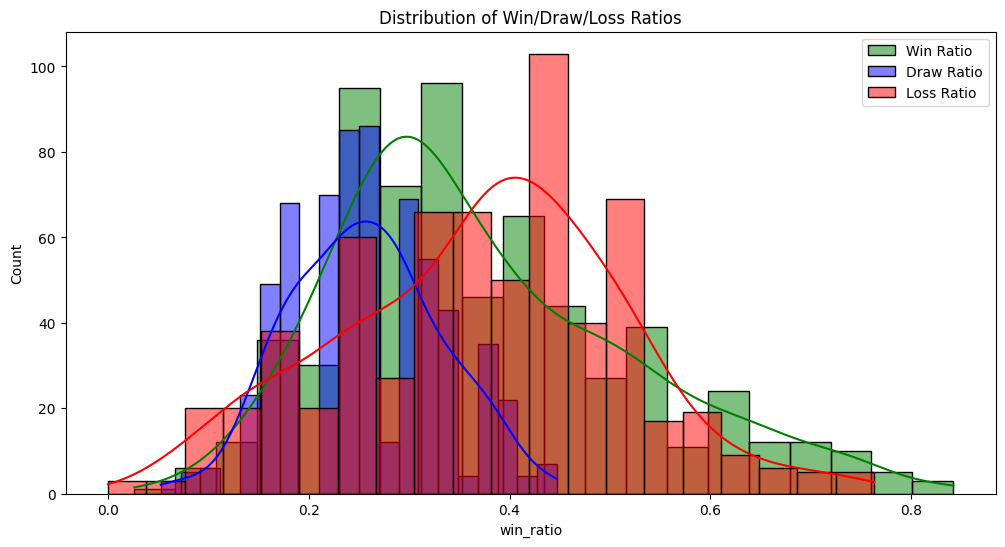

In [32]:
# 5. Exploratory Data Analysis (EDA)
# ========================

# --- Distribution of ratios
plt.figure(figsize=(12,6))
sns.histplot(df["win_ratio"], bins=20, color="green", kde=True, label="Win Ratio")
sns.histplot(df["draw_ratio"], bins=20, color="blue", kde=True, label="Draw Ratio")
sns.histplot(df["loss_ratio"], bins=20, color="red", kde=True, label="Loss Ratio")
plt.legend()
plt.title("Distribution of Win/Draw/Loss Ratios")
plt.show()

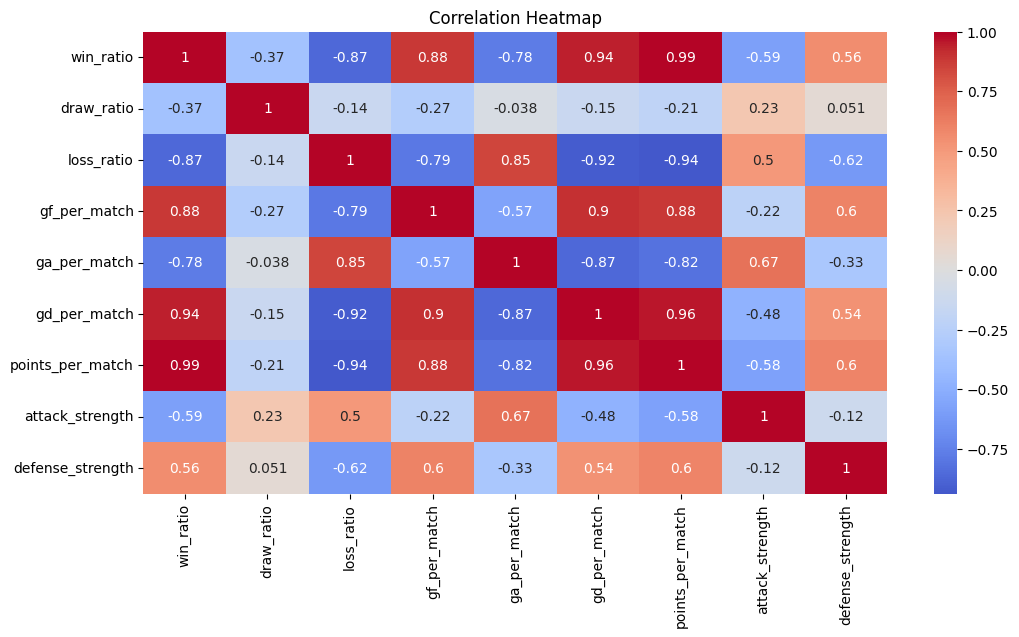

In [34]:
# --- Correlation heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df[["win_ratio","draw_ratio","loss_ratio","gf_per_match","ga_per_match",
                "gd_per_match","points_per_match","attack_strength","defense_strength"]].corr(),
            annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

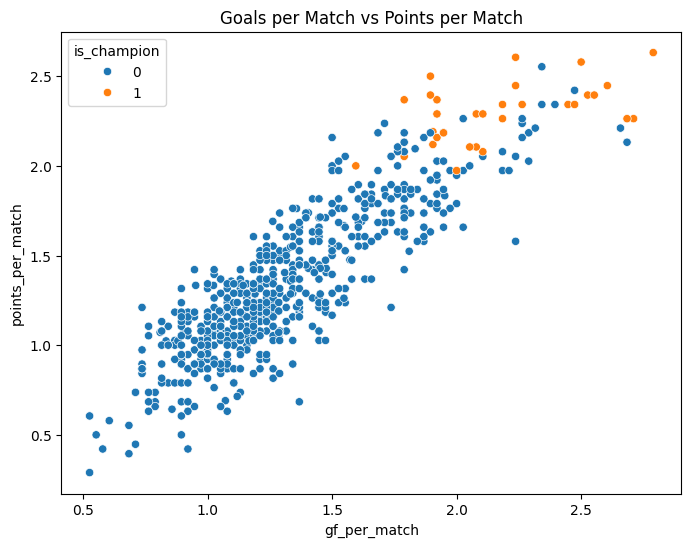

In [36]:
# --- Scatter: Goals vs Points
plt.figure(figsize=(8,6))
sns.scatterplot(x="gf_per_match", y="points_per_match", hue="is_champion", data=df)
plt.title("Goals per Match vs Points per Match")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_17696\3981468736.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_points.values, y=team_points.index, palette="viridis")


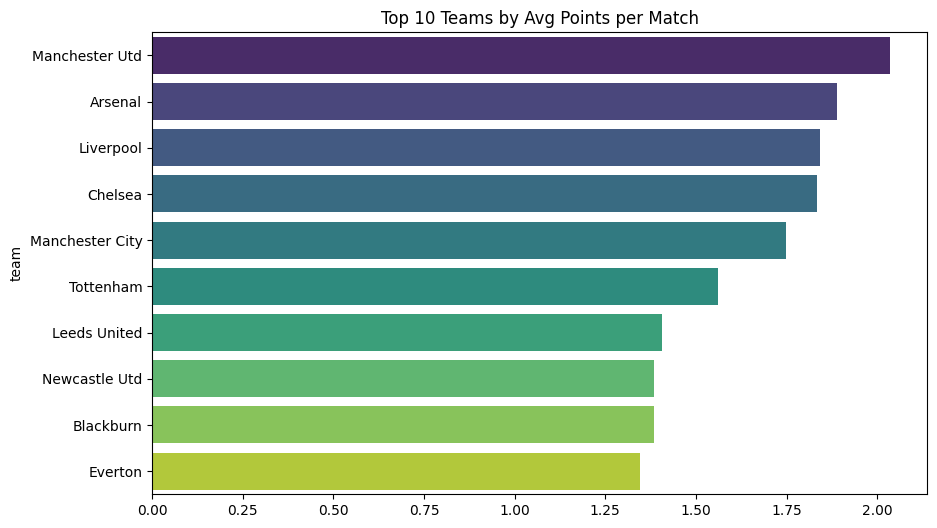

In [38]:
# --- Team wise performance trend
team_points = df.groupby("team")["points_per_match"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=team_points.values, y=team_points.index, palette="viridis")
plt.title("Top 10 Teams by Avg Points per Match")
plt.show()

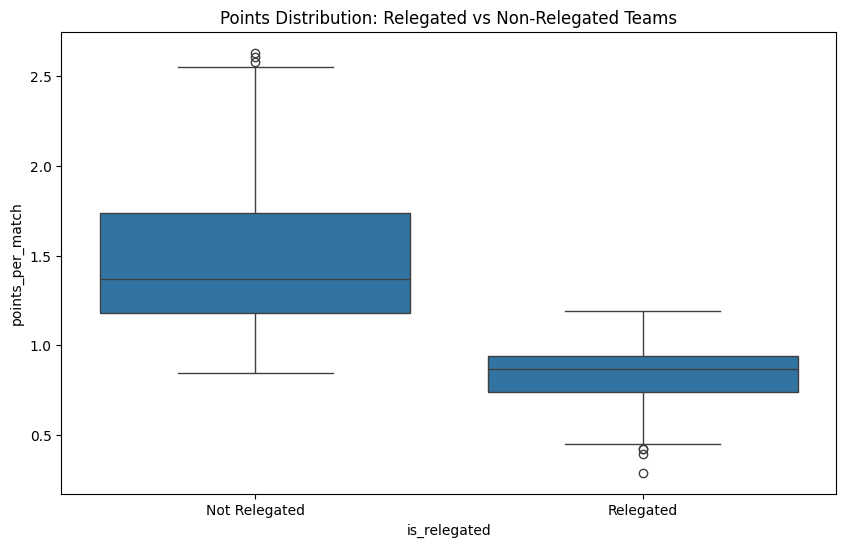

In [40]:
# --- Relegated teams analysis
plt.figure(figsize=(10,6))
sns.boxplot(x="is_relegated", y="points_per_match", data=df)
plt.title("Points Distribution: Relegated vs Non-Relegated Teams")
plt.xticks([0,1], ["Not Relegated","Relegated"])
plt.show()

In [54]:
#Outlier Detection using IQR
# Outlier detection using IQR with summary table
numeric_cols = ["played", "won", "drawn", "lost", "gf", "ga", "gd", "points"]

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": outliers.shape[0]
    })

outlier_df = pd.DataFrame(outlier_summary)
print("🔎 Outlier Summary Table:")
print(outlier_df)


🔎 Outlier Summary Table:
   Column     Q1     Q3    IQR  Lower Bound  Upper Bound  Outlier Count
0  played  38.00  38.00   0.00       38.000       38.000             66
1     won  10.00  18.00   8.00       -2.000       30.000              3
2   drawn   8.00  12.00   4.00        2.000       18.000              0
3    lost  10.25  18.00   7.75       -1.375       29.625              0
4      gf  41.00  60.75  19.75       11.375       90.375             13
5      ga  43.00  59.75  16.75       17.875       84.875              8
6      gd -17.00  15.00  32.00      -65.000       63.000             11
7  points  41.00  63.00  22.00        8.000       96.000              4


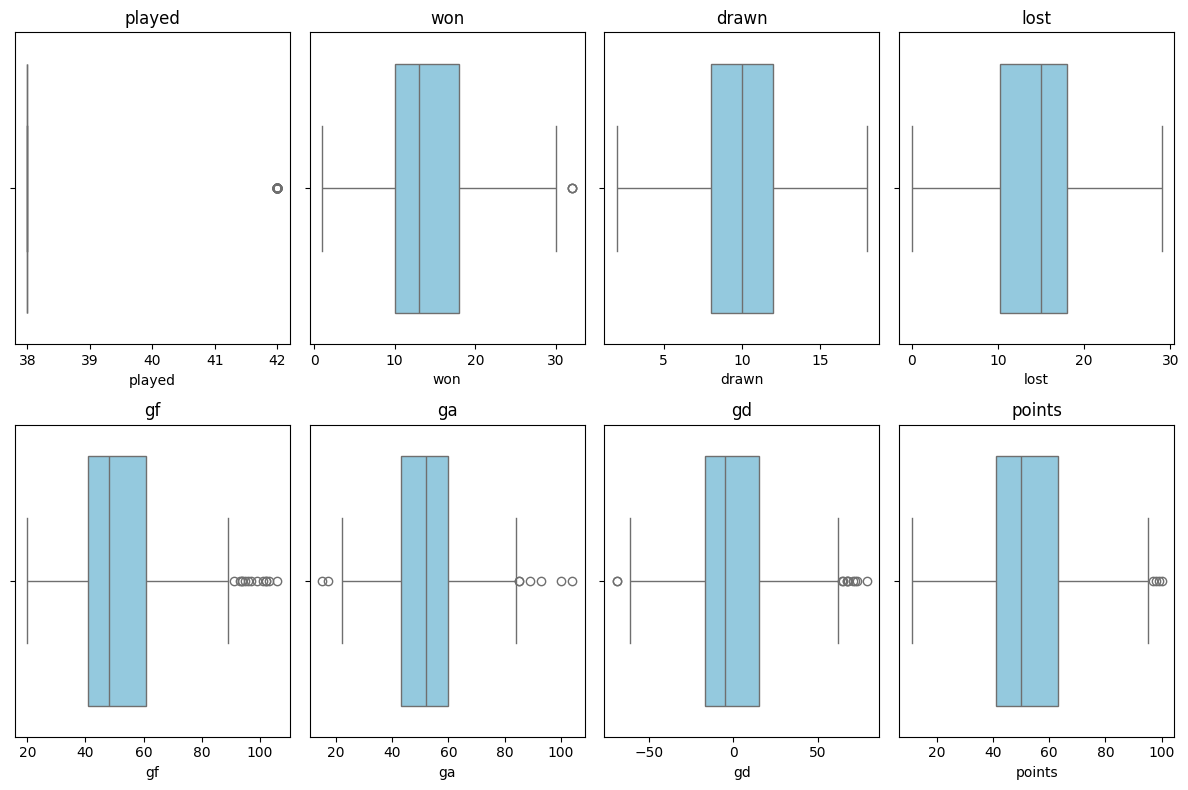

In [56]:
# Boxplots to visualize outliers
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

In [15]:
# Find categorical (object type) columns
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical Columns:", categorical_cols)

Categorical Columns: ['team', 'notes']


In [25]:
#Apply Label Encoding + One-Hot Encoding
from sklearn.preprocessing import LabelEncoder

# Dictionary to store fitted encoders
label_encoders = {}

# Apply Label Encoding on all categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col + "_LE"] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


print(df.head())

   season_end_year            team  position  played  won  drawn  lost  gf  \
0             1993  Manchester Utd         1      42   24     12     6  67   
1             1993     Aston Villa         2      42   21     11    10  57   
2             1993    Norwich City         3      42   21      9    12  61   
3             1993       Blackburn         4      42   20     11    11  68   
4             1993             QPR         5      42   17     12    13  63   

   ga  gd  points                                 notes  team_LE  notes_LE  
0  31  36      84  → Champions League via league finish       28        13  
1  40  17      74          → UEFA Cup via league finish        1        39  
2  65  -4      72        → UEFA Cup via league finish 1       31        40  
3  46  22      71                                   NaN        4         9  
4  55   8      63                                   NaN       35         9  


In [27]:
# Apply One-Hot Encoding
df_onehot = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


print(df_onehot.head())

   season_end_year  position  played  won  drawn  lost  gf  ga  gd  points  \
0             1993         1      42   24     12     6  67  31  36      84   
1             1993         2      42   21     11    10  57  40  17      74   
2             1993         3      42   21      9    12  61  65  -4      72   
3             1993         4      42   20     11    11  68  46  22      71   
4             1993         5      42   17     12    13  63  55   8      63   

   ...  notes_→ UEFA Cup via cup loss 1  notes_→ UEFA Cup via cup loss 2  \
0  ...                            False                            False   
1  ...                            False                            False   
2  ...                            False                            False   
3  ...                            False                            False   
4  ...                            False                            False   

   notes_→ UEFA Cup via cup win 1  notes_→ UEFA Cup via cup win 2  \
0    

In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load data
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\pl-tables-1993-2024.csv")

# 2. Encode all categorical columns except targets
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['points', 'position']]
df_encoded = pd.get_dummies(df, columns=cat_cols)

# 3. Prepare features and target
X = df_encoded.drop(columns=['points', 'position'])
y = (df['position'] <= 4).astype(int)  # Example: Top 4 classification

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Train and evaluate
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       102
           1       1.00      0.86      0.92        28

    accuracy                           0.97       130
   macro avg       0.98      0.93      0.95       130
weighted avg       0.97      0.97      0.97       130

Confusion Matrix:
 [[102   0]
 [  4  24]]
Accuracy: 0.9692


In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Model Train 
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_train)        # y_train = continuous/ordinal values (e.g. position or points)

# 2. Predict 
y_pred = reg.predict(X_test)

# 3. Metrics calculate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 4. Results print
print("Mean Absolute Error (MAE):", round(mae, 3))
print("Mean Squared Error (MSE):", round(mse, 3))
print("Root Mean Squared Error (RMSE):", round(rmse, 3))
print("R^2 Score:", round(r2, 3))

Mean Absolute Error (MAE): 0.034
Mean Squared Error (MSE): 0.018
Root Mean Squared Error (RMSE): 0.133
R^2 Score: 0.895


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Encode categorical columns 
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':  
        data[col] = le.fit_transform(data[col])

# --- Features & Target ---
X = data.drop("notes", axis=1)
y = data["notes"]

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Default Decision Tree ---
clf_default = DecisionTreeClassifier(random_state=42)
clf_default.fit(X_train, y_train)
y_pred_default = clf_default.predict(X_test)

print(" Default Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print("\nClassification Report:\n", classification_report(y_test, y_pred_default, zero_division=0))

# --- Show available hyperparameters ---
print("\n Decision Tree Hyperparameters:")
for param, val in clf_default.get_params().items():
    print(f"{param}: {val}")

# --- Hyperparameter Tuning with GridSearchCV ---
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_dt.fit(X_train, y_train)

print("\n Best Parameters:", grid_dt.best_params_)
best_dt = grid_dt.best_estimator_

# --- Tuned Decision Tree ---
y_pred_tuned = best_dt.predict(X_test)

print("\n Tuned Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned, zero_division=0))


📌 Default Decision Tree Results:
Accuracy: 0.7

Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         0
           8       0.94      0.89      0.91        18
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         0
          12       0.95      0.91      0.93        23
          18       0.00      0.00      0.00         1
          19       0.00      0.00      0.00         0
          21       0.20      0.33      0.25         3
          22       0.00      0.00      0.00         3
          23       1.00      0.50      0.67         2
          26       0.00      0.00      0.00         0
          27       0.00      0.00      0.00         0
          29       0.00      0.00      0.00         1
         

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



📌 Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}

📌 Tuned Decision Tree Results:
Accuracy: 0.7769230769230769

Classification Report:
               precision    recall  f1-score   support

           6       0.00      0.00      0.00         1
           8       1.00      0.94      0.97        18
           9       0.00      0.00      0.00         1
          12       0.95      0.91      0.93        23
          13       0.00      0.00      0.00         0
          18       0.00      0.00      0.00         1
          21       0.50      1.00      0.67         3
          22       0.00      0.00      0.00         3
          23       0.00      0.00      0.00         2
          29       0.00      0.00      0.00         1
          32       0.00      0.00      0.00         1
          34       0.00      0.00      0.00         1
          35       0.00      0.00      0.00         2
          38       0.29      0.67      0.40      

In [42]:
from imblearn.over_sampling import SMOTE
import pandas as pd



In [44]:
# --- Evaluate Model Function ---
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)

    print(f"\n {name} Results:")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    }

In [46]:
# --- Results List ---
results = []

In [48]:
# Default Decision Tree (Already Done)
results.append(
    evaluate_model("Decision Tree (Default)", clf_default, X_train, y_train, X_test, y_test)
)



📌 Decision Tree (Default) Results:
Accuracy: 0.7
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         0
           8       0.94      0.89      0.91        18
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         0
          12       0.95      0.91      0.93        23
          18       0.00      0.00      0.00         1
          19       0.00      0.00      0.00         0
          21       0.20      0.33      0.25         3
          22       0.00      0.00      0.00         3
          23       1.00      0.50      0.67         2
          26       0.00      0.00      0.00         0
          27       0.00      0.00      0.00         0
          29       0.00      0.00      0.00         1
          30       0.00      0.

In [50]:
# Tuned Decision Tree (Already Done)
results.append(
    evaluate_model("Decision Tree (Tuned)", best_dt, X_train, y_train, X_test, y_test)
)


📌 Decision Tree (Tuned) Results:
Accuracy: 0.7769230769230769
              precision    recall  f1-score   support

           6       0.00      0.00      0.00         1
           8       1.00      0.94      0.97        18
           9       0.00      0.00      0.00         1
          12       0.95      0.91      0.93        23
          13       0.00      0.00      0.00         0
          18       0.00      0.00      0.00         1
          21       0.50      1.00      0.67         3
          22       0.00      0.00      0.00         3
          23       0.00      0.00      0.00         2
          29       0.00      0.00      0.00         1
          32       0.00      0.00      0.00         1
          34       0.00      0.00      0.00         1
          35       0.00      0.00      0.00         2
          38       0.29      0.67      0.40         6
          39       0.00      0.00      0.00         4
          40       0.00      0.00      0.00         2
          42      

In [56]:
print(y_train.value_counts())


notes
43    260
12     84
8      73
38     17
21     16
42     10
19      5
22      3
35      3
36      3
23      3
34      2
10      2
40      2
17      2
13      2
39      2
31      2
14      2
15      1
11      1
33      1
41      1
32      1
7       1
30      1
24      1
0       1
20      1
27      1
26      1
29      1
25      1
5       1
16      1
2       1
1       1
37      1
18      1
4       1
3       1
28      1
Name: count, dtype: int64


In [64]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE, RandomOverSampler




# --- 3. SMOTE 
valid_classes = y_train.value_counts()[y_train.value_counts() > 5].index
X_train_filtered = X_train[y_train.isin(valid_classes)]
y_train_filtered = y_train[y_train.isin(valid_classes)]

smote = SMOTE(random_state=42, k_neighbors=2)
X_train_sm, y_train_sm = smote.fit_resample(X_train_filtered, y_train_filtered)

dt_smote = DecisionTreeClassifier(random_state=42)
evaluate_model(dt_smote, X_train_sm, y_train_sm, X_test, y_test, "Decision Tree with SMOTE (>5 samples classes)")

# --- 4. RandomOverSampler 
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

dt_ros = DecisionTreeClassifier(random_state=42)
evaluate_model(dt_ros, X_train_ros, y_train_ros, X_test, y_test, "Decision Tree with RandomOverSampler (All Classes)")

# --- Results Table ---
results_df = pd.DataFrame(results)
print("\n📊 Comparison Table:\n")
print(results_df)

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(



📌 Decision Tree with SMOTE (>5 samples classes)
Accuracy: 0.7615384615384615

Classification Report:
               precision    recall  f1-score   support

           6       0.00      0.00      0.00         1
           8       0.95      1.00      0.97        18
           9       0.00      0.00      0.00         1
          12       0.86      0.78      0.82        23
          18       0.00      0.00      0.00         1
          21       0.38      1.00      0.55         3
          22       0.00      0.00      0.00         3
          23       0.00      0.00      0.00         2
          29       0.00      0.00      0.00         1
          32       0.00      0.00      0.00         1
          34       0.00      0.00      0.00         1
          35       0.00      0.00      0.00         2
          38       0.42      0.83      0.56         6
          39       0.00      0.00      0.00         4
          40       0.00      0.00      0.00         2
          42       0.17      1.0